# Initialisation

* `src()` works well in the previous workflow whereas the current call does not (with yellow wave under the functions which actually are called).

In [10]:
year          = 2023
loc_json = "json/location_params.json"
geo_json      = 'json/geo_params.json'
default_json  = 'json/default_params.json'
config_json   = 'json/UQ_null.json'
epw_path      = '../src/_base/epw/ED-TMYx.2023.epw'
occupancyProfile_csv = 'ETHlib/auxiliary/schedules_el_OFFICE.csv'

In [11]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import json

ROOT = Path.cwd().parent.resolve()
RC_SIMULATOR = "ETHlib"
if str(RC_SIMULATOR) not in sys.path:
    sys.path.insert(0, str(RC_SIMULATOR))

from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system
from radiation import Location, Window

CITYLOC       = json.loads(Path(loc_json).read_text())
latitude_deg = CITYLOC['latitude_deg']
longitude_deg  = CITYLOC['longitude_deg']
EDI            = Location(epwfile_path=epw_path)
GEOMETRY       = json.loads(Path(geo_json).read_text())
DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
occupancyProfile = pd.read_csv(occupancyProfile_csv)

In [12]:
meter_path = "_data/Metering_ISO.csv"
meter_daily = load_meter_heating(meter_path, "Main Heating", GEOMETRY["FLOOR_AREA"], "D")
meter_hourly = load_meter_heating(meter_path, "Main Heating", GEOMETRY["FLOOR_AREA"], "h")

Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00


# ETH_package

* Ventilation is not calculated as an airflow network. It is simplified into a single heat-loss conductance between indoor air and supply/outdoor air
* Parameter definition
    * "_alpha"     :     3,   # coefficient for 'area of surfaces facing the room'
    * "_beta"      :     0.3, # coefficient for 'south windows'

# Test_1

In [14]:
res_orig, eui_orig, _ = run_model(
    sampled_params = {},
    controller_mode="original"
)

res_occ, eui_occ, _ = run_model(
    sampled_params = {},
    controller_mode="occupancy"
)

In [15]:
res_orig, eui_orig, office_orig = run_model(
    sampled_params={},
    controller_mode="original"
)

# Now get the debug log from the Office object
debug_df = office_orig.get_debug_dataframe()
debug_df.index = res_orig.index   # align with hourly DatetimeIndex
sample = debug_df.loc['2023-02-03 18:00':'2023-02-04 08:00',
                       ['has_heating_demand', 't_air_free', 'heating_setpoint', 'energy_demand']]
print(sample)

                     has_heating_demand  t_air_free  heating_setpoint  \
2023-02-03 18:00:00               False   18.071666              18.0   
2023-02-03 19:00:00                True   17.891920              18.0   
2023-02-03 20:00:00                True   17.802238              18.0   
2023-02-03 21:00:00                True   17.718726              18.0   
2023-02-03 22:00:00                True   17.582127              18.0   
2023-02-03 23:00:00                True   17.479416              18.0   
2023-02-04 00:00:00                True   17.410726              18.0   
2023-02-04 01:00:00                True   17.346762              18.0   
2023-02-04 02:00:00                True   17.287201              18.0   
2023-02-04 03:00:00                True   17.231738              18.0   
2023-02-04 04:00:00                True   17.180092              18.0   
2023-02-04 05:00:00                True   17.190834              18.0   
2023-02-04 06:00:00                True   17.117514

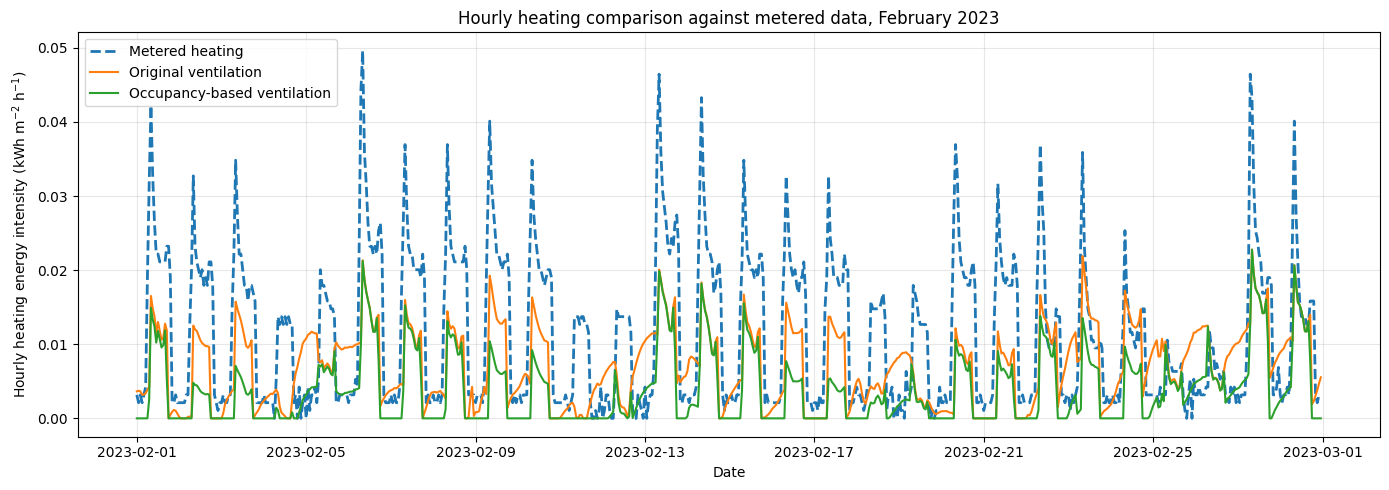

In [16]:
start = "2023-02-01 00:00"
end   = "2023-02-28 23:00"

res_orig_feb = res_orig.loc[start:end].copy()
res_occ_feb  = res_occ.loc[start:end].copy()
meter_feb    = meter_hourly.loc[start:end].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    meter_feb.index,
    meter_feb,
    label="Metered heating",
    linewidth=2.0,
    linestyle="--"
)

plt.plot(
    res_orig_feb.index,
    res_orig_feb["HeatingEnergy"],
    label="Original ventilation",
    linewidth=1.5
)

plt.plot(
    res_occ_feb.index,
    res_occ_feb["HeatingEnergy"],
    label="Occupancy-based ventilation",
    linewidth=1.5
)

plt.ylabel("Hourly heating energy intensity (kWh m$^{-2}$ h$^{-1}$)")
plt.xlabel("Date")
plt.title("Hourly heating comparison against metered data, February 2023")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test-2

In [17]:
occupancy_cases = {
    "occ_1p5_0p5": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.5,
        "occupancy_threshold": 100,
    },
    "occ_1p5_0p3": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.3,
        "occupancy_threshold": 100,
    },
    "occ_1p5_0p1": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.1,
        "occupancy_threshold": 100,
    },
    "occ_1p0_0p3": {
        "occupied_ach": 1.0,
        "unoccupied_ach": 0.3,
        "occupancy_threshold": 100,
    },
    "occ_1p0_0p5": {
        "occupied_ach": 1.0,
        "unoccupied_ach": 0.5,
        "occupancy_threshold": 100,
    },
}

results = {}
euis = {}

# Original constant-ventilation case
results["original"], euis["original"], _ = run_model(
    sampled_params={},
    controller_mode="original",
)

results["occupancy_default"], euis["occupancy_default"], _ = run_model(
    sampled_params={},
    controller_mode="occupancy",
)

for case_name, ctrl_params in occupancy_cases.items():
    results[case_name], euis[case_name], _ = run_model(
        sampled_params={},
        controller_mode="occupancy",
        occupancy_controller_params=ctrl_params,
    )
    
    
comparison = []

for case_name, res in results.items():

    if case_name == "original":
        controller_type = "constant baseline"
        occupied_ach = res["ach_vent"].iloc[0]
        unoccupied_ach = np.nan
        occupancy_threshold = np.nan

    elif case_name == "occupancy_default":
        controller_type = "occupancy default"
        occupied_ach = res["ach_vent"].max()
        unoccupied_ach = res["ach_vent"].min()
        occupancy_threshold = 0.1 * DEFAULT_PARAMS["max_occupancy"]

    else:
        controller_type = "occupancy manual"
        ctrl_params = occupancy_cases[case_name]
        occupied_ach = ctrl_params["occupied_ach"]
        unoccupied_ach = ctrl_params["unoccupied_ach"]
        occupancy_threshold = ctrl_params["occupancy_threshold"]

    comparison.append({
        "case": case_name,
        "controller_type": controller_type,

        # Controller settings or inferred effective values
        "occupied_ach": occupied_ach,
        "unoccupied_ach": unoccupied_ach,
        "occupancy_threshold": occupancy_threshold,

        # Physical ventilation states
        "mean_ach_vent": res["ach_vent"].mean(),
        "min_ach_vent": res["ach_vent"].min(),
        "max_ach_vent": res["ach_vent"].max(),
        "mean_ach_infl": res["ach_infl"].mean(),

        # Energy outcomes
        "heating_eui": res["HeatingEnergy"].sum(),
        "cooling_eui": res["CoolingEnergy"].sum(),
        "total_hvac_eui": (
            res["HeatingEnergy"].sum()
            + res["CoolingEnergy"].sum()
        ),
    })

comparison_df = pd.DataFrame(comparison).set_index("case")

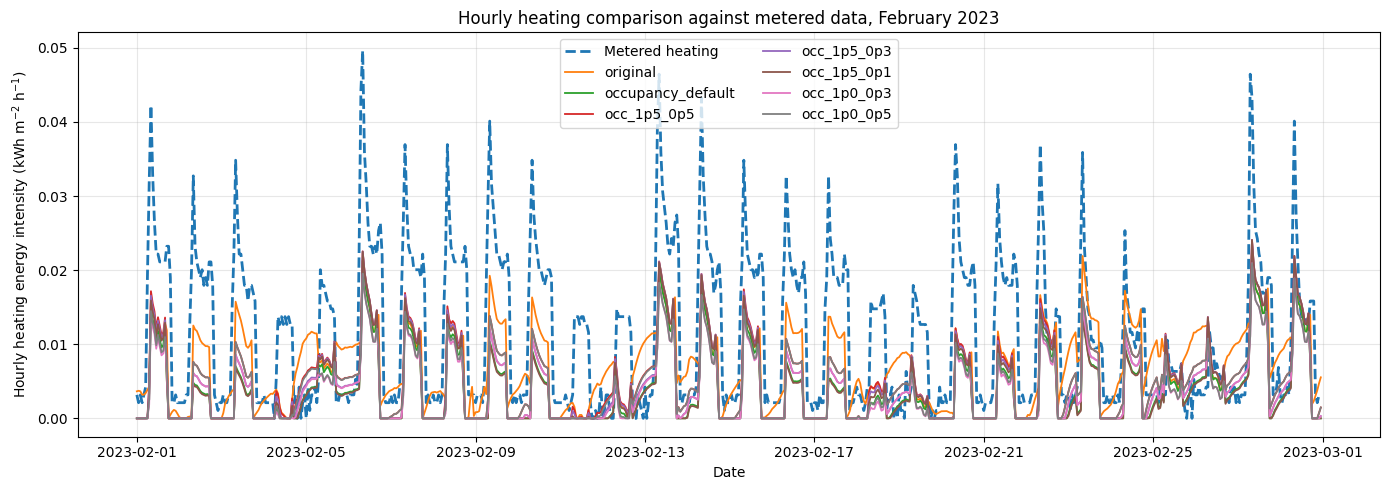

In [18]:
start = "2023-02-01 00:00"
end   = "2023-02-28 23:00"

meter_feb = meter_hourly.loc[start:end].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    meter_feb.index,
    meter_feb,
    label="Metered heating",
    linewidth=2.0,
    linestyle="--",
)

for case_name, res in results.items():
    res_feb = res.loc[start:end].copy()

    plt.plot(
        res_feb.index,
        res_feb["HeatingEnergy"],
        label=case_name,
        linewidth=1.3,
    )

plt.ylabel(r"Hourly heating energy intensity (kWh m$^{-2}$ h$^{-1}$)")
plt.xlabel("Date")
plt.title("Hourly heating comparison against metered data, February 2023")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()